# 04 - Theme mentions over time (two signals)

**What this does:** builds TWO complementary theme signals and saves them
side by side, so you can see whether they agree:

1. **KEYWORD signal** — scans each post in the slice saved by **notebook 01**
   (`data/processed/posts_slice.parquet`) for curated words/phrases per theme.
   A post about "HBM memory pricing" scores for `memory` even with no ticker.
   Each post counts once per theme; weighting is score² (same rules as the
   ticker pipeline, so the two signals are directly comparable).
2. **INFERRED signal** — maps the daily ticker counts (notebook 02's output,
   `daily_ticker_counts.parquet`) onto themes: NVDA implies the AI trade,
   SHEL implies energy, GME implies meme stocks. A ticker can feed several
   themes. This signal is free — no post scanning at all.

The chain is: **01 (slice) → 02 (ticker counts) → 04 (theme signals) → 05
(take-offs)**. Note 04 now needs notebook 02's output too (for the inferred
signal); run 02 before 04.

Saves `data/processed/daily_theme_counts.parquet` with columns:
`date, theme, keyword_count, keyword_weighted, inferred_count, inferred_weighted`.

The keyword scanner is a single tokenisation pass + hash lookups
(~15k posts/sec — the full 2.8M-post year takes ~3 minutes, down from ~80).

Edit `THEME_KEYWORDS` (words/phrases) and `THEME_TICKERS` (ticker→theme
mapping) in `src/themes.py` to add or tune themes.

In [1]:
import os, sys
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
print('project root:', ROOT)

project root: c:\Users\alexd\Desktop\GIC\RetailFlow1


In [2]:
# ============ PARAMETERS - edit these ============
# NOTE: no TIME WINDOW here. The window and subreddits come from notebook 01,
# via the slice file it saves - one source of truth for the chain.
SLICE_PATH         = os.path.join(ROOT, 'data', 'processed', 'posts_slice.parquet')
TICKER_COUNTS_PATH = os.path.join(ROOT, 'data', 'processed', 'daily_ticker_counts.parquet')
THEMES_TO_PLOT     = []      # e.g. ['ai', 'gold_metals']; [] = use the TOP_N most mentioned
TOP_N              = 6
DAILY_THEMES_OUT   = os.path.join(ROOT, 'data', 'processed', 'daily_theme_counts.parquet')
# ==================================================

In [ ]:
import pandas as pd

# Force-reload src.themes so an already-running kernel picks up edits to
# THEME_KEYWORDS / THEME_TICKERS without a restart.
import importlib
import src.themes
importlib.reload(src.themes)
from src.themes import (build_daily_theme_counts, build_inferred_theme_counts,
                        combine_theme_signals, THEME_KEYWORDS, THEME_TICKERS)

# Input 1: the cleaned slice saved by notebook 01 - THIS is how 04 inherits
# 01's TIME WINDOW and SUBREDDITS. No filters are re-declared here.
if not os.path.exists(SLICE_PATH):
    raise FileNotFoundError(
        'posts_slice.parquet not found - run notebook 01 first '
        '(it saves the cleaned slice this notebook reads).')

# Input 2: notebook 02's daily ticker counts - the INFERRED signal maps
# these onto themes (NVDA -> ai, SHEL -> energy ...).
if not os.path.exists(TICKER_COUNTS_PATH):
    raise FileNotFoundError(
        'daily_ticker_counts.parquet not found - run notebook 02 first '
        '(the inferred theme signal is built from its ticker counts).')

posts = pd.read_parquet(SLICE_PATH, columns=['date', 'title', 'selftext', 'score'])
print('posts:', f'{len(posts):,}', '| window:', posts['date'].min(), '->', posts['date'].max())
print('themes defined:', sorted(THEME_KEYWORDS.keys()))

# SIGNAL 1 - keyword scan (~15k posts/sec; a full year takes ~3 min).
keyword_daily = build_daily_theme_counts(posts)
print('keyword signal rows:', len(keyword_daily))

# SIGNAL 2 - inferred from ticker counts (instant - just a groupby).
ticker_counts = pd.read_parquet(TICKER_COUNTS_PATH)
inferred_daily = build_inferred_theme_counts(ticker_counts)
print('inferred signal rows:', len(inferred_daily))

# Combine: one row per (date, theme), zeros where a signal is silent.
daily = combine_theme_signals(keyword_daily, inferred_daily)
daily.to_parquet(DAILY_THEMES_OUT, index=False)
print('combined rows:', len(daily), '-> saved', DAILY_THEMES_OUT)
daily.head()

posts: 2,833,008 | window: 2021-01-01 -> 2021-12-31
themes defined: ['ai', 'ai_megacap', 'biotech_pharma', 'china_geopolitics', 'cloud_saas', 'consumer_retail', 'crypto', 'datacenters', 'defense_aerospace', 'energy', 'europe_defense', 'ev_clean_energy', 'financials', 'gold_metals', 'meme_stocks', 'memory', 'rates_bonds', 'real_estate', 'semiconductors', 'short_squeeze', 'uranium_nuclear']


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
daily['date'] = pd.to_datetime(daily['date'])

def format_date_axis(ax, rotate=45):
    """Weekly (Monday) YYYY-MM-DD ticks - same axis style as notebook 03."""
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    for label in ax.get_xticklabels():
        label.set_rotation(rotate)
        label.set_ha('right')
        label.set_fontsize(7)
    ax.grid(True, which='major', axis='x', alpha=0.3)

def annotate_series_peak(ax, x, y, color=None):
    """Write the EXACT date of a line's highest day next to that point."""
    y = pd.Series(y).reset_index(drop=True)
    x = pd.Series(x).reset_index(drop=True)
    if len(y) == 0 or y.max() <= 0:
        return
    i = y.idxmax()
    ax.annotate(pd.Timestamp(x.iloc[i]).strftime('%Y-%m-%d'), (x.iloc[i], y.iloc[i]),
                textcoords='offset points', xytext=(0, 6), ha='center',
                fontsize=7, color=color)

# Decide which themes to draw (ranked by the keyword signal).
if THEMES_TO_PLOT:
    chosen = THEMES_TO_PLOT
else:
    totals = daily.groupby('theme')['keyword_count'].sum().sort_values(ascending=False)
    chosen = list(totals.head(TOP_N).index)
print('plotting:', chosen)

def plot_signal(column, title, ylabel):
    fig, ax = plt.subplots(figsize=(13, 6))
    for theme in chosen:
        one = daily[daily['theme'] == theme].sort_values('date')
        line, = ax.plot(one['date'], one[column], marker='o', markersize=3, label=theme)
        annotate_series_peak(ax, one['date'], one[column], color=line.get_color())
    ax.set_title(title + " (labels = each line's peak day)")
    ax.set_xlabel('date'); ax.set_ylabel(ylabel)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    format_date_axis(ax)
    plt.tight_layout()
    plt.show()

plotting: ['crypto', 'meme_stocks', 'short_squeeze', 'financials', 'ai_megacap', 'consumer_retail']


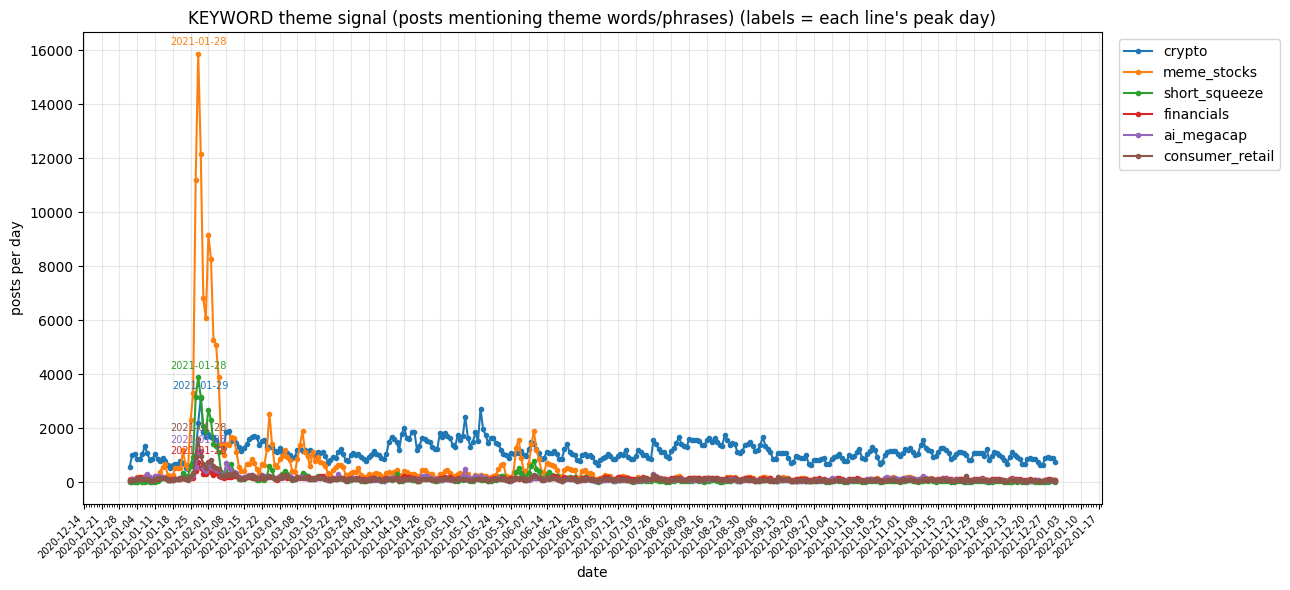

In [ ]:
# GRAPH 1 - keyword signal: posts per day whose text mentions the theme
plot_signal('keyword_count', 'KEYWORD theme signal (posts mentioning theme words/phrases)', 'posts per day')

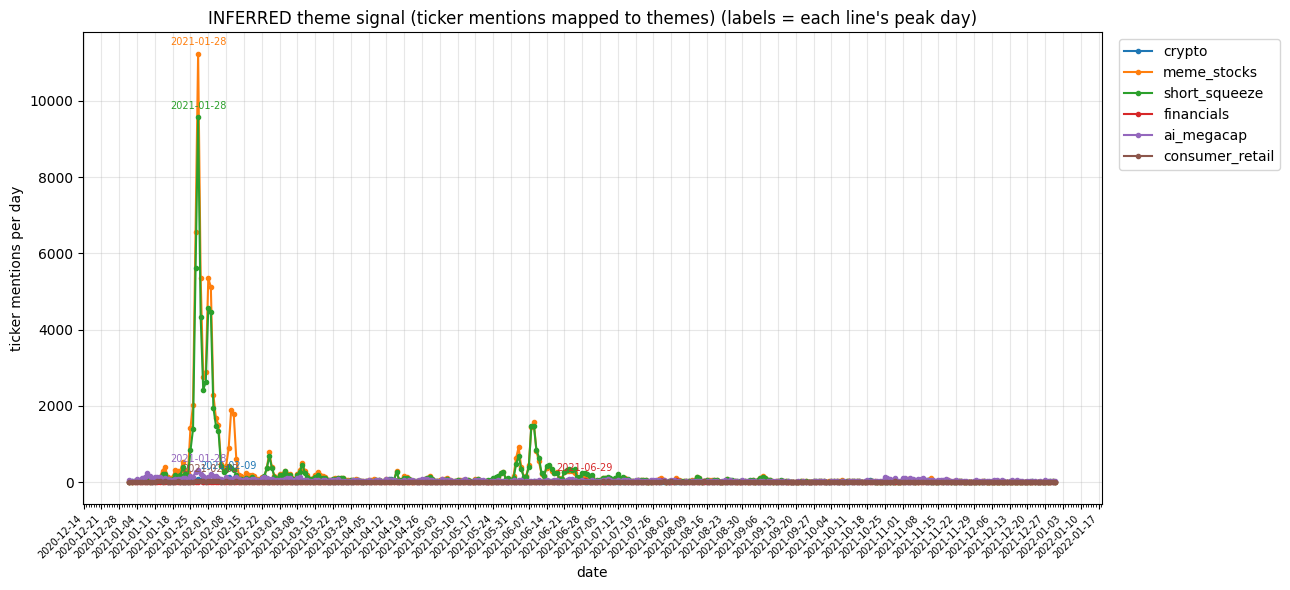

In [ ]:
# GRAPH 2 - inferred signal: ticker mentions rolled up into themes
plot_signal('inferred_count', 'INFERRED theme signal (ticker mentions mapped to themes)', 'ticker mentions per day')

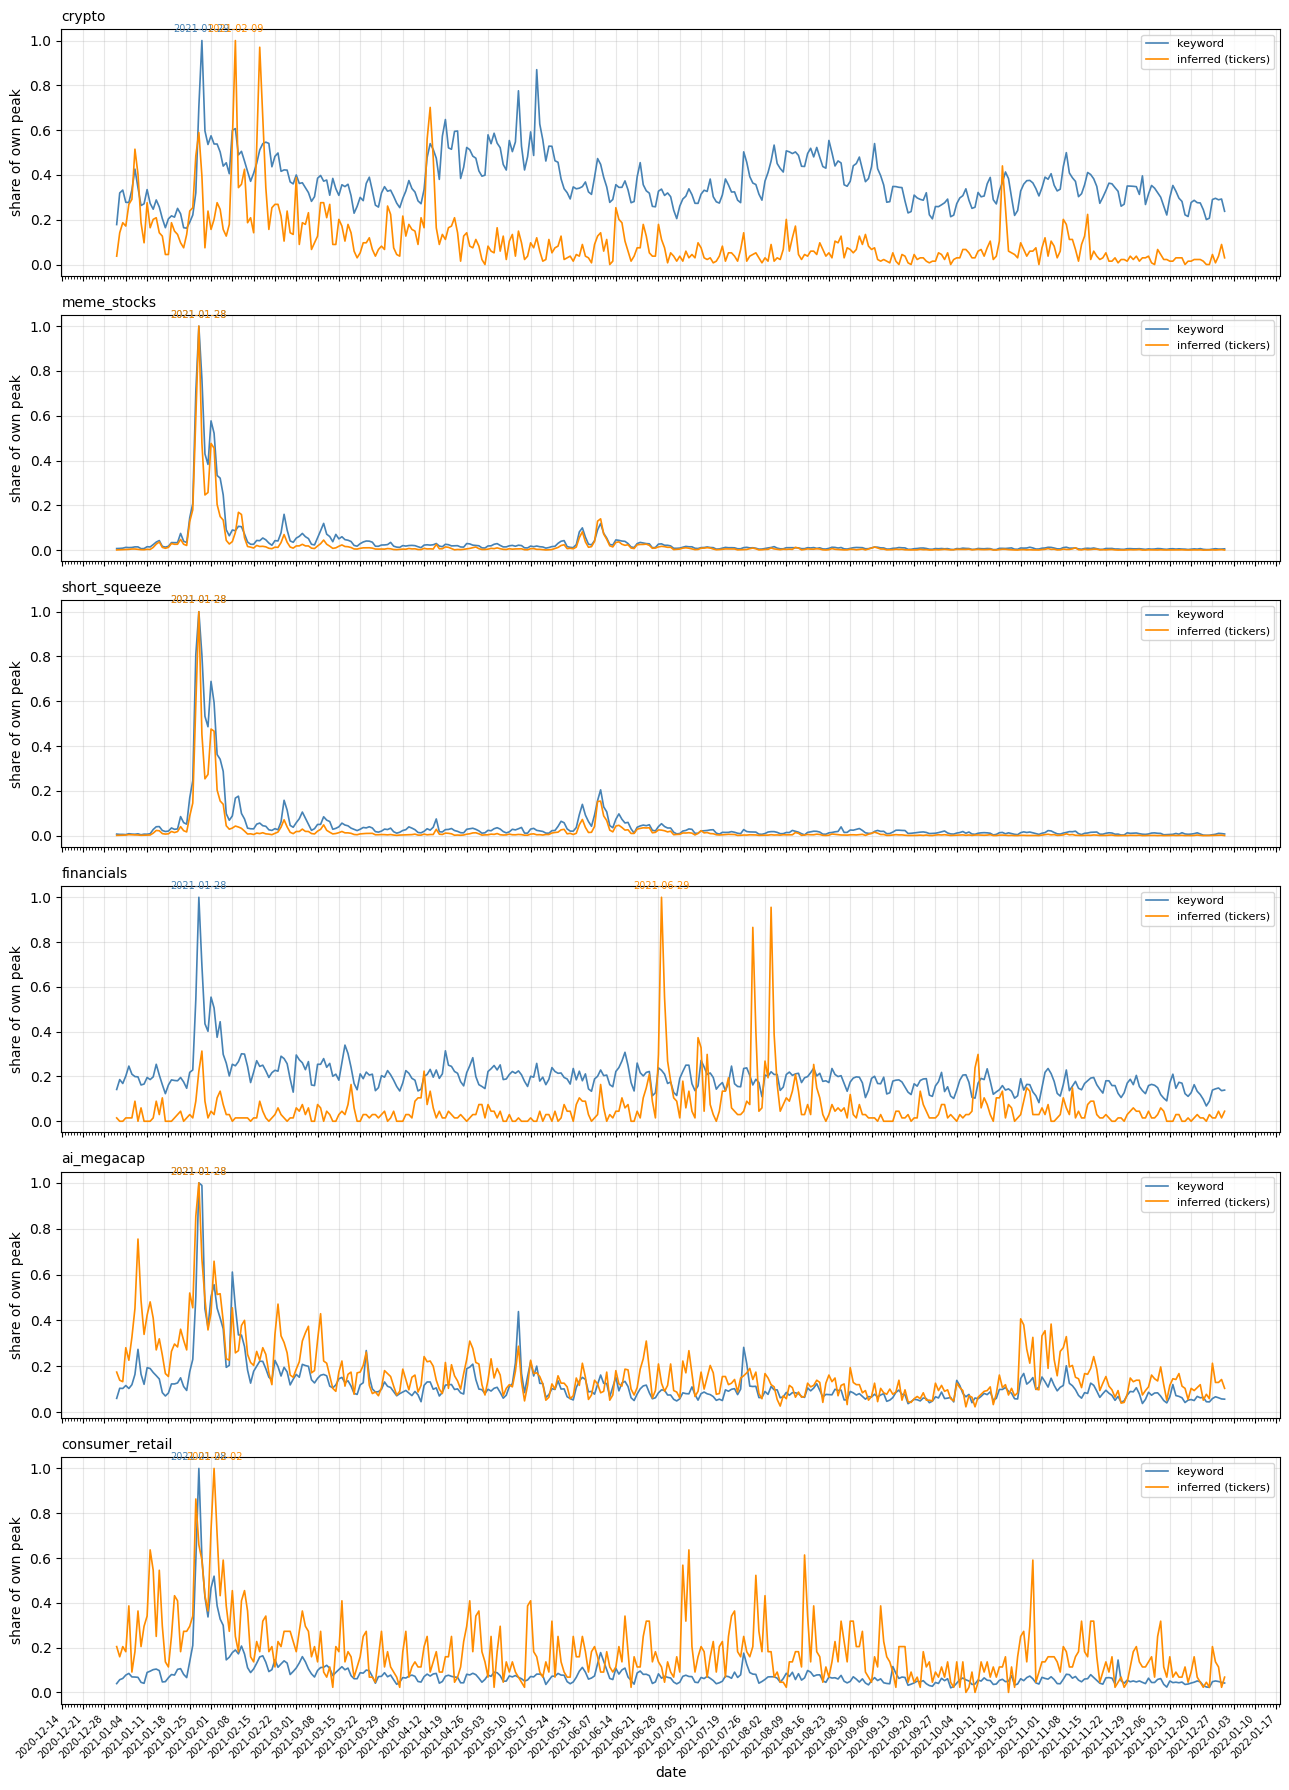

In [ ]:
# GRAPH 3 - do the two signals agree? One panel per theme, both lines.
# Different y-scales (posts vs ticker mentions), so each line is normalised
# to its own maximum - the SHAPE agreement is what matters: if both spike
# together, the theme move is real; if only one does, investigate which.
# Each line's peak day is labelled with its exact date.
import numpy as np

fig, axes = plt.subplots(len(chosen), 1, figsize=(13, 3 * len(chosen)), sharex=True)
if len(chosen) == 1:
    axes = [axes]
for ax, theme in zip(axes, chosen):
    one = daily[daily['theme'] == theme].sort_values('date')
    for col, color, label in [('keyword_count', 'steelblue', 'keyword'),
                              ('inferred_count', 'darkorange', 'inferred (tickers)')]:
        peak = one[col].max()
        if peak > 0:
            ax.plot(one['date'], one[col] / peak, color=color, linewidth=1.2, label=label)
            annotate_series_peak(ax, one['date'], one[col] / peak, color=color)
    ax.set_title(theme, fontsize=10, loc='left')
    ax.set_ylabel('share of own peak')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
format_date_axis(axes[-1])
axes[-1].set_xlabel('date')
plt.tight_layout(); plt.show()

In [ ]:
# Summary table: totals per theme, both signals side by side.
# A theme strong in keyword but weak in inferred = talked about without
# tickers (macro, options chatter). Strong in inferred but weak in keyword =
# people trade the names without naming the theme.
summary = (
    daily.groupby('theme')
    .agg(keyword_total=('keyword_count', 'sum'),
         inferred_total=('inferred_count', 'sum'),
         keyword_weighted=('keyword_weighted', 'sum'),
         inferred_weighted=('inferred_weighted', 'sum'),
         days_active=('date', 'nunique'))
    .sort_values('keyword_total', ascending=False)
)
summary

,keyword_total,inferred_total,keyword_weighted,inferred_weighted,days_active
theme,,,,,
crypto,424456,5246,0,0,365
meme_stocks,203669,88937,0,0,365
short_squeeze,62161,73966,0,0,365
financials,53529,1472,0,0,365
ai_megacap,50681,19323,0,0,365
consumer_retail,48274,2985,0,0,365
ev_clean_energy,35961,15048,0,0,365
rates_bonds,28969,81,0,0,365
gold_metals,28436,1202,0,0,365
